# Setup (LangChain Legacy Agents Compatibility Fix)

This notebook uses **LangChain legacy agents** (e.g. `AgentExecutor`, `create_tool_calling_agent`), which are **not compatible with the latest LangChain releases** shipped in Colab by default.

To avoid version conflicts:

1. Uninstall any preinstalled `numpy`, `pandas`, and `langchain*` packages.
2. Install a set of versions that are known to work with the legacy agents used in this notebook.

> **Important:** After running the two cells below,   
> you **must restart the runtime** (`Runtime → Restart session`) before continuing.  
> If you do not restart, Python may still use the old in-memory versions, and imports / agents can fail in confusing ways.

In [ ]:
# Uninstall the conflicting packages to start fresh
!pip uninstall -y numpy pandas langchain langchain-core langchain-community langchain-openai


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: langchain 1.2.0
Uninstalling langchain-1.2.0:
  Successfully uninstalled langchain-1.2.0
Found existing installation: langchain-core 1.2.1
Uninstalling langchain-core-1.2.1:
  Successfully uninstalled langchain-core-1.2.1


In [ ]:
# Install the exact compatible stack for Colab + Legacy Agents
!pip install -q "numpy==1.26.4" \
                "pandas==2.2.2" \
                "scikit-learn" \
                "langchain==0.3.0" \
                "langchain-core==0.3.0" \
                "langchain-community==0.3.0" \
                "langchain-openai==0.2.0" \
                "vaderSentiment"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.1/405.1 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not curren

**IMPORTANT REMINDER:** Now restart the runtime (Runtime → Restart session) before running the next cells.

# Setup (Dependencies & Imports)

Install dependencies, clone the repo, and import required libraries and modules.

In [ ]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 260, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 260 (delta 46), reused 30 (delta 14), pack-reused 171 (from 1)
Receiving objects: 100% (260/260), 19.61 MiB | 18.03 MiB/s, done.
Resolving deltas: 100% (134/134), done.


In [ ]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import json
import base64
import time
import subprocess

from tqdm import tqdm
from PIL import Image
from numpy.linalg import norm

# ML/DL libraries
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer, util
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import confusion_matrix, classification_report

# LangChain
from langchain.tools import tool
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Import custom utility for OpenAI Client
from utils.api_key import load_openai_client

In [ ]:
# Set OpenAI API
client = load_openai_client()

# Metadata (Dataset Loading & Preparation)

Load the Fakeddit metadata, clean it, and select the subset of samples containing valid image URLs.

In [ ]:
# Unzip fakeddit_images.zip from /content/FakeNews/assets/content/master_pipeline_assets/
!unzip -q /content/FakeNews/assets/fakeddit_images.zip -d /content/FakeNews/assets

In [ ]:
# Load the pre-processed metadata
subset_path = "/content/FakeNews/assets/fakeddit_balanced_subset.csv"
image_df = pd.read_csv(subset_path)

# Define the path for the image directory (which was unzipped)
img_dir = "/content/FakeNews/assets/content/fakeddit_images"

# Update the DataFrame paths to reflect the new location
image_df['image_path'] = image_df['image_path'].apply(
    lambda p: os.path.join(img_dir, os.path.basename(p))
)

print(f"Loaded {len(image_df)} clean samples.")
print("Shape subset:", image_df.shape)
print(image_df["label"].value_counts())
image_df.head()


Loaded 150 clean samples.
Shape subset: (150, 5)
label
0    75
1    75
Name: count, dtype: int64


,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,bernie sander announces his campaign for presi...,0,https://preview.redd.it/m0yhjb563ek21.jpg?widt...,"yoda is sitting in a chair with the caption, ""..."
1,/content/FakeNews/assets/content/fakeddit_imag...,my dom nsfw,0,https://external-preview.redd.it/N5dbbbo3nx7uw...,a woman is standing in front of microphones
2,/content/FakeNews/assets/content/fakeddit_imag...,my inlaws moved into a building that hasnt upd...,1,https://preview.redd.it/knd5hhyozny21.jpg?widt...,a room with purple walls and green furniture
3,/content/FakeNews/assets/content/fakeddit_imag...,a leaf fell perfectly in the wet cement,1,https://preview.redd.it/70y4l9yhcsc31.jpg?widt...,a leaf on the sidewalk
4,/content/FakeNews/assets/content/fakeddit_imag...,a philadelphia bar cut a hall of famers baseba...,1,https://preview.redd.it/0ksailoiupe31.jpg?widt...,a baseball card with a picture of a man on it


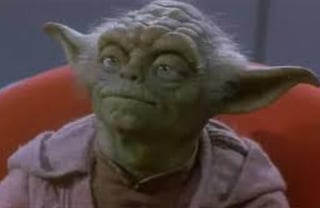

In [ ]:
# Test a sample
Image.open(image_df["image_path"].iloc[0])


In [ ]:
# Load visual concepts list
assets_dir = "/content/FakeNews/assets"
with open(os.path.join(assets_dir, "concepts_list.json"), "r") as f:
    concepts_list = json.load(f)

# Load visual concept embeddings
concept_embs = np.load(os.path.join(assets_dir, "concept_embeddings.npy"))
print(f"Loaded {len(concepts_list)} concepts and embedding matrix {concept_embs.shape}")

Loaded 1365 concepts and embedding matrix (1365, 512)


# Model & Tools

Lood all the models and define the LangChain tools.

In [ ]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Log GPU specs (model, driver, VRAM)
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,driver_version,memory.total", "--format=csv,noheader"],
        text=True
    ).strip()
    gpu_name, driver_version, vram_total = [x.strip() for x in smi.split(",")]
except Exception:
    gpu_name, driver_version, vram_total = "CPU/Unknown", None, None

In [ ]:
# CLIP
clip_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_name)
clip_processor = CLIPProcessor.from_pretrained(clip_name)
clip_model.to(device)
clip_model.eval()
print("\n-----------------------------------------------------")
print("CLIP loaded successfully.")
print("-----------------------------------------------------")

# RoBERTa
roberta_name = "yaoyinnan/roberta-fakeddit"  # pretrained on Fakeddit dataset
roberta_tok = AutoTokenizer.from_pretrained(roberta_name)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_name)
roberta_model.to(device)
roberta_model.eval()
print("\n-----------------------------------------------------")
print("RoBERTa loaded successfully.")
print("-----------------------------------------------------")

# SentenceTransformer
sim_model = SentenceTransformer("all-mpnet-base-v2")
sim_model.to(device)
print("\n-----------------------------------------------------")
print("MPNet loaded successfully.")
print("-----------------------------------------------------")

# Sentiment Heuristic (VADER)
vader_analyzer = SentimentIntensityAnalyzer()

print("\n-----------------------------------------------------")
print("All models loaded successfully.")
print("-----------------------------------------------------")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


-----------------------------------------------------
MPNet loaded successfully.
-----------------------------------------------------

-----------------------------------------------------
All models loaded successfully.
-----------------------------------------------------


## Vision Tool

Gather all visual evidence through BLIP and CLIP.

In [ ]:
# Define labels for CLIP prompts
label_prompts = [
    "a staged or manipulated fake news photo",
    "a real photo from a legitimate news report"
]

In [ ]:
@tool
def vision_tool(image_path: str) -> dict:
    """
    Analyzes an image file.
    Returns: top visual concepts (CLIP), and Fake/Real classification (CLIP Zero-Shot).
    """
    image = Image.open(image_path).convert("RGB")

    # CLIP features (for concepts and zero-shot)
    inputs = clip_processor(images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        img_emb = clip_model.get_image_features(**inputs)
    img_vec = img_emb.squeeze().cpu().numpy()

    # 1. Top-K Concepts
    k=5
    img_vec_norm = img_vec / norm(img_vec)
    concept_mags = norm(concept_embs, axis=1)
    concept_embs_norm = concept_embs / concept_mags[:, np.newaxis]
    sims = concept_embs_norm @ img_vec_norm
    topk_idx = sims.argsort()[::-1][:k]
    topk = [f"{concepts_list[i]} ({sims[i]:.2f})" for i in topk_idx]

    # 2. CLIP Zero-Shot
    text_inputs = clip_processor(text=label_prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_embs = clip_model.get_text_features(**text_inputs)

    # Calculate similarity for ZS (manual dot product)
    text_embs_norm = text_embs / text_embs.norm(dim=1, keepdim=True)
    img_emb_norm = img_emb / img_emb.norm(dim=1, keepdim=True)
    logits = (img_emb_norm @ text_embs_norm.T).squeeze()
    probs = logits.softmax(dim=0).cpu().numpy()

    zs_pred_idx = np.argmax(probs)
    zs_label = "Real" if zs_pred_idx == 1 else "Fake"
    zs_conf = float(probs[zs_pred_idx])

    return {

            "visual_concepts": topk,
            "clip_zs_label": zs_label,
            "clip_zs_confidence": zs_conf
    }


## Text Tool

Gather all textual evidence through RoBERTa and VADER.

In [ ]:
@tool
def text_tool(user_text: str) -> dict:
    """
    Analyzes the User Headline and computes VADER sentiment for the headline only.
    Returns: RoBERTa classification and VADER scores for the User Headline.
    """
    results = {}

    # 1. RoBERTa Classification
    inputs = roberta_tok(user_text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        out = roberta_model(**inputs)
        probs = F.softmax(out.logits, dim=1).squeeze()

    pred_idx = torch.argmax(probs).item()
    label = "Fake" if pred_idx == 0 else "Real"
    conf = float(probs[pred_idx])

    # 2. VADER Sentiment
    sentiment = vader_analyzer.polarity_scores(user_text)["compound"]

    return {
        "roberta_label": label,
        "roberta_conf": conf,
        "vader_sentiment": sentiment
    }


## Consistency Tools

Gather all multimodal alignment evidence through MPNet and CLIP.

In [ ]:
@tool
def consistency_tool(user_text: str, AI_caption: str, image_path: str) -> dict:
    """
    Computes two-way alignment scores:
    1. Semantic: Text vs Caption
    2. Cross-modal: Image vs Text (User Claim Alignment)
    """
    # 1. Semantic Similarity (MPNet - Text-to-Text)
    emb1 = sim_model.encode(user_text, convert_to_tensor=True, device=device)
    emb2 = sim_model.encode(AI_caption, convert_to_tensor=True, device=device)
    st_sim = util.cos_sim(emb1, emb2).item()

    # 2. Cross-Modal Similarity (CLIP - Image-to-Text)
    image = Image.open(image_path).convert("RGB")

    # Get separate image & text features
    image_inputs = clip_processor(images=image, return_tensors="pt").to(device)
    text_inputs = clip_processor(text=[user_text], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        img_feats = clip_model.get_image_features(**image_inputs)
        txt_feats = clip_model.get_text_features(**text_inputs)

    # Normalize to unit length
    img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
    txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)

    # Cosine similarity: dot product of normalized vectors
    img_text_sim = float((img_feats @ txt_feats.T).squeeze().item())  # in [-1, 1]

    return {
        "text_to_caption_similarity": st_sim,
        "image_to_text_similarity": img_text_sim
    }


# Agentic Reasoning (GPT Fusion Layer)

Provide reasoning and final decision through GPT.

In [ ]:
# Agent setup
tools = [vision_tool, text_tool, consistency_tool]

# Define the System Prompt
system_prompt = """
You are a Misinformation Detection Expert Analyst.
Your goal is to distinguish between **Malicious Fake News** and **Benign Content** using a "See, Then Verify" workflow.

CORE PHILOSOPHY:
Trust your eyes first, then verify with forensic tools. Be willing to change your mind if the tools reveal invisible details.

YOUR TOOLKIT:
1. Vision Tool:
   - Detects visual concepts in the image.
   - Flags the image as potentially Fake or Real using a vision classifier.
2. Text Tool:
   - Analyzes the user-provided headline.
   - Flags the headline as potentially Fake or Real using a fake-news classifier.
   - Measures sentiment (e.g., sensationalism) using sentiment analysis.
3. Consistency Tool:
   - Measures how well the image, AI description, and headline align using semantic and cross-modal similarity:
     - text_to_caption_similarity: cosine similarity between headline and AI caption (range [-1, 1]).
     - image_to_text_similarity: cosine similarity between image and headline (range [-1, 1]).

IMPORTANT TOOL RULES:
- Before giving your final answer, you MUST call:
  - vision_tool
  - text_tool
  - consistency_tool
- Use the actual tool outputs as evidence. Do NOT invent or fabricate tool results.
- You may change your initial intuition if the tools provide strong contradictory evidence.

DATA GATHERING PROTOCOL:

PHASE 1: DIRECT OBSERVATION (System 1 Intuition)
- For your initial impression, you MUST rely ONLY on the provided IMAGE and HEADLINE.
- IGNORE the AI image description in this phase.
- Then choose your initial impression: "Real" or "Fake", and explain briefly WHY based on what you SEE in the image and READ in the headline.

PHASE 2: IMAGE DESCRIPTION RELIABILITY (Reliability Check)
- You are provided with an AI-generated Image Description.
- Compare this description with the image.
- Is the description accurate?
  - If YES: Tool scores that rely on this description are trustworthy (e.g., text_to_caption_similarity from the consistency_tool).
  - If NO: The description might be hallucinated or vague. Be sceptical about tool scores based on this description and rely more on your own visual interpretation and other tools.

PHASE 3: FORENSIC CONSULTATION (System 2 Forensics)
- Call vision_tool to:
  - Check which visual concepts are detected.
  - See whether the image is predicted as Fake or Real, and with what confidence.
- Call text_tool to:
  - Check whether the headline is predicted as Fake or Real, and with what confidence.
  - Inspect its sentiment score (e.g., very extreme or sensational tone).
- Call consistency_tool to:
  - Measure alignment between:
    - Headline and AI caption (semantic similarity).
    - Image and Headline (cross-modal similarity).
  - High values near 1.0 indicate strong alignment, values near 0 indicate weak or generic alignment, and values below 0 indicate contradiction.

PHASE 4: SYNTHESIS (The Verdict)
- Compare Phase 1 (Intuition) with Phase 3 (Forensics).
- Check whether the tools found something you missed.
- Reflect explicitly: did the tools change your mind?
- Then choose a final classification: "Real" or "Fake".

CONFIDENCE FIELD:
When setting "Decision_Confidence":
- Use "High" if most tools strongly agree with each other and with your final decision.
- Use "Medium" if the evidence is mixed but clearly leans toward your final decision.
- Use "Low" if the evidence is weak or conflicting and you had to choose despite uncertainty.

OUTPUT FORMAT:
Return a single JSON object (no markdown, no extra commentary), with this exact structure:

{{
  "Initial_Impression": "Real" or "Fake",
  "Initial_Reasoning": "Brief summary of your initial impression.",
  "Final_Decision": "Real" or "Fake",
  "Did_Decision_Change": "Yes" or "No",
  "Decision_Confidence": "High" or "Medium" or "Low",
  "Explanation": "Detailed narrative. Start with your intuition, mention whether the AI description was reliable, and explain how the tool evidence confirmed or refuted your initial thought.",
  "Nudge": "One actionable piece of advice for the user about how to think more critically about similar content in the future."
}}

"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0) # or gpt-4o-mini
agent = create_tool_calling_agent(llm, tools, prompt)


In [ ]:
# Helper to encode image for GPT
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [ ]:
# Make Verbose=False to keep output clean
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=False)

# Run pipeline
results = []

# Start timer
T0 = time.perf_counter()

# Iterate through the DataFrame
for i, row in tqdm(image_df.iterrows(), total=len(image_df)): # use sample_df for N samples
    current_image_path = row['image_path']
    current_headline = row['clean_title']
    current_AIcaption = row['blip2_caption']
    true_label = row['label']

    # 1. Encode Image
    base64_img = encode_image(current_image_path)

    # 2. Create Structured Input (Text + Image)
    user_input = [
        {
            "type": "text",
            "text": f"""
Please analyze this news item using your tools.

HEADLINE: "{current_headline}"
AI_IMAGE_DESCRIPTION: "{current_AIcaption}"
LOCAL_IMAGE_PATH: "{current_image_path}"

Use this LOCAL_IMAGE_PATH string exactly when calling:
- vision_tool(image_path=LOCAL_IMAGE_PATH)
- consistency_tool(user_text=HEADLINE, AI_caption=AI_IMAGE_DESCRIPTION, image_path=LOCAL_IMAGE_PATH)

The actual image is also attached for your direct visual observation.
            """.strip()
        },
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}
        }
    ]

    try:
        # Run the Agent
        response = agent_executor.invoke({"input": user_input})

        # Extract output
        output_text = response['output']

        # Clean markdown code blocks if present
        clean_json = output_text.replace("```json", "").replace("```", "").strip()

        # Parse JSON output
        decision_data = json.loads(clean_json)

        # Baseline predictions (CLIP & RoBERTa)
        vision_res = vision_tool.invoke({"image_path": current_image_path})
        text_res   = text_tool.invoke({"user_text": current_headline})

        # Store all fields
        results.append({
            "image_path": current_image_path,
            "headline": current_headline,
            "true_label": true_label,
            "blip2_caption": current_AIcaption,

            # Tool predictions
            "clip_label": vision_res.get("clip_zs_label"),
            "roberta_label": text_res.get("roberta_label"),

            # Decision fields
            "initial_impression": decision_data.get("Initial_Impression"),
            "initial_reasoning": decision_data.get("Initial_Reasoning"),
            "final_decision": decision_data.get("Final_Decision"),
            "changed_mind": decision_data.get("Did_Decision_Change"),
            "confidence": decision_data.get("Decision_Confidence"),

            # Explanation
            "explanation": decision_data.get("Explanation"),
            "nudge": decision_data.get("Nudge"),

            # Debugging
            "raw_output": output_text
        })

    except Exception as e:
        print(f"Error on row {i}: {e}")
        results.append({
            "image_path": current_image_path,
            "headline": current_headline,
            "error": str(e)
        })

# Stop timer
T1 = time.perf_counter()
print(f"\nTotal runtime: {(T1 - T0)/60:.2f} min  ({T1 - T0:.1f} sec)")

# Save results
results_df = pd.DataFrame(results)
print("\nProcessing Complete.")
results_df.head()


 10%|█         | 15/150 [02:00<17:12,  7.65s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
 19%|█▉        | 29/150 [03:58<15:44,  7.81s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.1


Total runtime: 20.13 min  (1207.8 sec)

Processing Complete.


,image_path,headline,true_label,blip2_caption,clip_label,roberta_label,initial_impression,initial_reasoning,final_decision,changed_mind,confidence,explanation,nudge,raw_output
0,/content/FakeNews/assets/content/fakeddit_imag...,bernie sander announces his campaign for presi...,0,"yoda is sitting in a chair with the caption, ""...",Real,Fake,Fake,The headline claims Bernie Sanders announces a...,Fake,No,High,"Initially, the headline about Bernie Sanders' ...",Always check if the image content matches the ...,"{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."
1,/content/FakeNews/assets/content/fakeddit_imag...,my dom nsfw,0,a woman is standing in front of microphones,Fake,Fake,Fake,The headline 'my dom nsfw' is vague and suspic...,Fake,No,High,"Initially, the headline seemed suspicious and ...","Be cautious of headlines that are vague, nonse...","{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."
2,/content/FakeNews/assets/content/fakeddit_imag...,my inlaws moved into a building that hasnt upd...,1,a room with purple walls and green furniture,Real,Real,Real,The image shows a room with purple walls and g...,Real,No,High,My initial impression was that the news item i...,When evaluating news items about places or set...,"{\n ""Initial_Impression"": ""Real"",\n ""Initial..."
3,/content/FakeNews/assets/content/fakeddit_imag...,a leaf fell perfectly in the wet cement,1,a leaf on the sidewalk,Real,Real,Real,The image shows a leaf on a cement surface tha...,Real,No,High,My initial impression was that the news item i...,"When evaluating similar content, pay close att...","{\n ""Initial_Impression"": ""Real"",\n ""Initial..."
4,/content/FakeNews/assets/content/fakeddit_imag...,a philadelphia bar cut a hall of famers baseba...,1,a baseball card with a picture of a man on it,Real,Real,Fake,The headline claims a Philadelphia bar cut a H...,Real,Yes,Medium,"Initially, the headline seemed suspicious beca...",When encountering unusual or surprising claims...,"{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."


# Detailed Evaluation (Performance Comparisons)

Compare classification performances: CLIP, RoBERTa, GPT pre-fuse, GPT post-fuse.

In [ ]:
# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None  # for errors / missing / unexpected values

# Make a new df for evaluation
eval_df = pd.DataFrame({
    "true_label": results_df["true_label"].astype(int),
    "clip_label": results_df["clip_label"].apply(label_to_int),
    "robertaT_label": results_df["roberta_label"].apply(label_to_int),
    "gpt_pre":  results_df["initial_impression"].apply(label_to_int),
    "gpt_post": results_df["final_decision"].apply(label_to_int),
})


In [ ]:
# Accuracies
clip_acc     = np.mean(eval_df["clip_label"]     == eval_df["true_label"])
robertaT_acc = np.mean(eval_df["robertaT_label"] == eval_df["true_label"])
gpt1_acc     = np.mean(eval_df["gpt_pre"]        == eval_df["true_label"])
gpt2_acc     = np.mean(eval_df["gpt_post"]       == eval_df["true_label"])

print("CLIP (Vision) accuracy:", round(clip_acc, 3))
print("RoBERTa (Text-Headline) accuracy:", round(robertaT_acc, 3))
print("GPT (Pre-Fuse) accuracy:", round(gpt1_acc, 3))
print("GPT (Post-Fuse) accuracy:", round(gpt2_acc, 3))


CLIP (Vision) accuracy: 0.493
RoBERTa (Text-Headline) accuracy: 0.94
GPT (Pre-Fuse) accuracy: 0.633
GPT (Post-Fuse) accuracy: 0.833


In [ ]:
# Confusion matrices

# CLIP CM
clip_cm = confusion_matrix(eval_df["true_label"], eval_df["clip_label"])

# RoBERTa CM
robertaT_cm = confusion_matrix(eval_df["true_label"], eval_df["robertaT_label"])

# GPT pre-fuse CM
gpt1_cm = confusion_matrix(eval_df["true_label"], eval_df["gpt_pre"])

# GPT post-fuse CM
gpt2_cm = confusion_matrix(eval_df["true_label"], eval_df["gpt_post"])

print("\nCLIP (Vision) Confusion Matrix:\n", clip_cm)
print("\nRoBERTa (Text-Headline) Confusion Matrix:\n", robertaT_cm)
print("\nGPT (Pre-Fuse) Confusion Matrix:\n", gpt1_cm)
print("\nGPT (Post-Fuse) Confusion Matrix:\n", gpt2_cm)



CLIP (Vision) Confusion Matrix:
 [[14 61]
 [15 60]]

RoBERTa (Text-Headline) Confusion Matrix:
 [[72  3]
 [ 6 69]]

GPT (Pre-Fuse) Confusion Matrix:
 [[59 16]
 [39 36]]

GPT (Post-Fuse) Confusion Matrix:
 [[72  3]
 [22 53]]


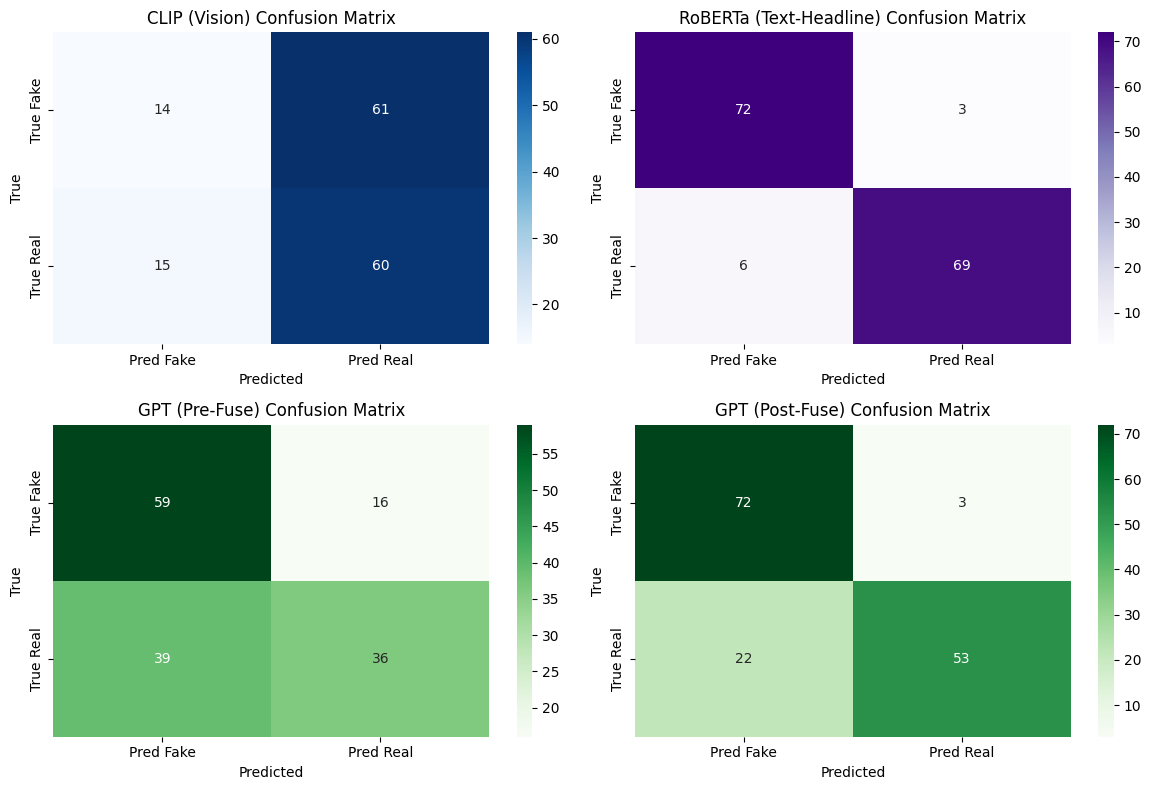

In [ ]:
# Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()  # flatten to 1D: axes[0]..axes[3]

sns.heatmap(clip_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[0])
axes[0].set_title("CLIP (Vision) Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(robertaT_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[1])
axes[1].set_title("RoBERTa (Text-Headline) Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

sns.heatmap(gpt1_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[2])
axes[2].set_title("GPT (Pre-Fuse) Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

sns.heatmap(gpt2_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[3])
axes[3].set_title("GPT (Post-Fuse) Confusion Matrix")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("True")

plt.tight_layout()
plt.show()

In [ ]:
# Classification reports
print("\n-----------------------------------------------------")
print("CLIP (Vision) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["clip_label"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("RoBERTa (Text-Headline) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["robertaT_label"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("GPT (Pre-Fuse) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["gpt_pre"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("GPT (Post-Fuse) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["gpt_post"],
    target_names=["Fake", "Real"]
))


-----------------------------------------------------
CLIP (Vision) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.48      0.19      0.27        75
        Real       0.50      0.80      0.61        75

    accuracy                           0.49       150
   macro avg       0.49      0.49      0.44       150
weighted avg       0.49      0.49      0.44       150


-----------------------------------------------------
RoBERTa (Text-Headline) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.92      0.96      0.94        75
        Real       0.96      0.92      0.94        75

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150


-------------------------------------------

# Log

In [ ]:
# Show runtime
runtime_sec = T1 - T0
print(f"Total runtime: {runtime_sec/60:.2f} min ({runtime_sec:.1f} sec)")

# Show GPU specs
display(gpu_name, driver_version, vram_total)

Total runtime: 20.13 min (1207.8 sec)


'NVIDIA L4'

'550.54.15'

'23034 MiB'

In [ ]:
# Log runtime and gpu specs
log = {
    "pipeline": "Single_Agent_Fusion_Vision",
    "n_samples": len(image_df),
    "runtime_sec": runtime_sec,
    "gpu_name": gpu_name,
    "driver_version": driver_version,
    "vram_total": vram_total,
}
print(log)

{'pipeline': 'Single_Agent_Fusion_Vision', 'n_samples': 150, 'runtime_sec': 1207.7809282750004, 'gpu_name': 'NVIDIA L4', 'driver_version': '550.54.15', 'vram_total': '23034 MiB'}


# Save

In [ ]:
# Save logs
with open("SAFv_runtime_log.jsonl", "a") as f:
    f.write(json.dumps(log) + "\n")

In [ ]:
# Save results_df
results_df.to_csv("SAFv_results_df.csv", index=False)

# Save eval_df
eval_df.to_csv("SAFv_eval_df.csv", index=False)
